In [1]:
%pip cache purge
%pip install -r ../requirements.txt


Files removed: 16 (68.7 MB)
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.python.org/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import shutil

import warnings
from time import time
import seaborn as sns
sns.set(rc={'figure.figsize':(12,8)})

# mne import
import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import concatenate_raws
from mne.io.edf import read_raw_edf
from mne.datasets import eegbci
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs, corrmap, Xdawn)
from mne.time_frequency import AverageTFR
from mne.channels import make_standard_montage
from mne.decoding import LinearModel, Vectorizer, get_coef, Scaler, CSP, SPoC, UnsupervisedSpatialFilter
# from mne.time_frequency import psd_welch
mne.set_log_level('WARNING')

import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [3]:


DIRECTORIES = [
    "../models", 
    "../data/raw/files",
	"../plots",
]
deleted_files = []

for directory in DIRECTORIES:
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        continue

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if item == ".gitkeep":
            continue  # Skip .gitkeep

        if os.path.isfile(item_path):
            os.remove(item_path)
            deleted_files.append(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            deleted_files.append(item_path + "/")  

if deleted_files:
    print("Deleted files and directories:")
    for file in deleted_files:
        print(f" - {file}")
else:
    print("No files to delete.")



No files to delete.


In [4]:
subject = [1] # 1, 4
run_execution = [5, 9, 13]
run_imagery = [6, 10, 14]

raw_files = []

for person_number in subject:
    for i, j in zip(run_execution, run_imagery):
        raw_files_execution = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, i)]
        raw_files_imagery = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, j)]
        
        raw_execution = concatenate_raws(raw_files_execution)
        raw_imagery = concatenate_raws(raw_files_imagery)

        events, _ = mne.events_from_annotations(raw_execution, event_id=dict(T0=1,T1=2,T2=3))
        mapping = {1:'rest', 2: 'do/feet', 3: 'do/hands'}
        annot_from_events = mne.annotations_from_events(
            events=events, event_desc=mapping, sfreq=raw_execution.info['sfreq'],
            orig_time=raw_execution.info['meas_date'])
        raw_execution.set_annotations(annot_from_events)
        
        events, _ = mne.events_from_annotations(raw_imagery, event_id=dict(T0=1,T1=2,T2=3))
        mapping = {1:'rest', 2: 'imagine/feet', 3: 'imagine/hands'}
        annot_from_events = mne.annotations_from_events(
            events=events, event_desc=mapping, sfreq=raw_imagery.info['sfreq'],
            orig_time=raw_imagery.info['meas_date'])
        raw_imagery.set_annotations(annot_from_events)
        
        
        raw_files.append(raw_execution)
        raw_files.append(raw_imagery)


In [5]:
raw_files


[<RawEDF | S001R05.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R09.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R10.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R13.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R14.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>]

In [6]:
raw = concatenate_raws(raw_files)
events, event_dict = mne.events_from_annotations(raw)
print(raw.info)
print(event_dict)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
{'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4, 'rest': 5}


In [7]:
picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
print (picks)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


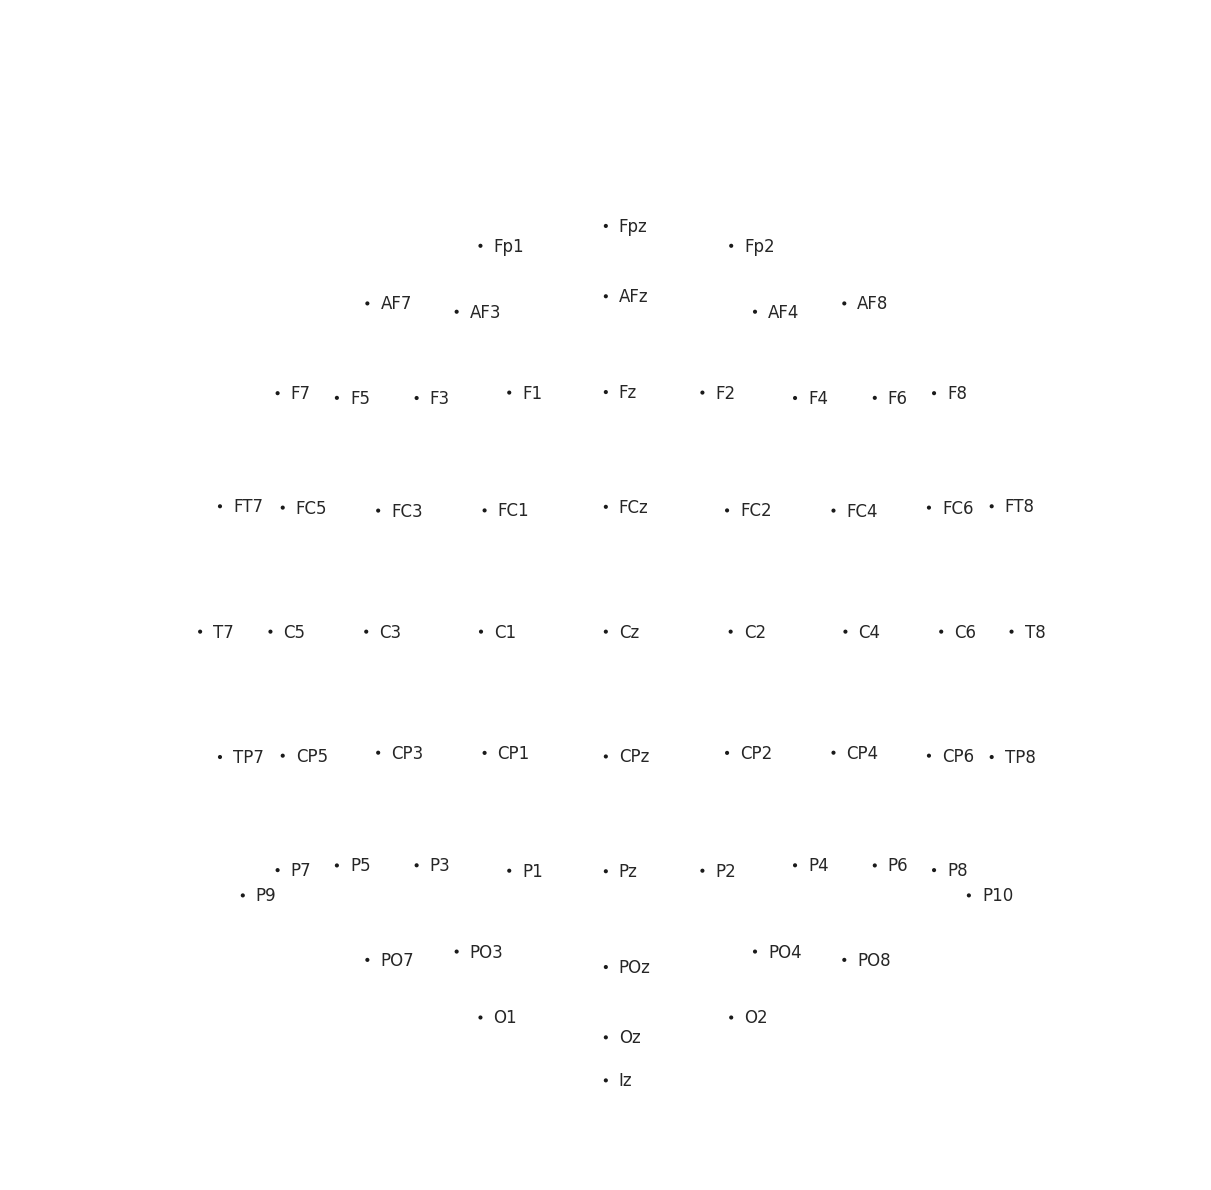

In [8]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
biosemi_montage.plot()
plt.show()


In [9]:
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage('standard_1005')
raw.set_montage(montage)


<RawEDF | S001R05.edf, 64 x 120000 (750.0 s), ~58.7 MiB, data loaded>

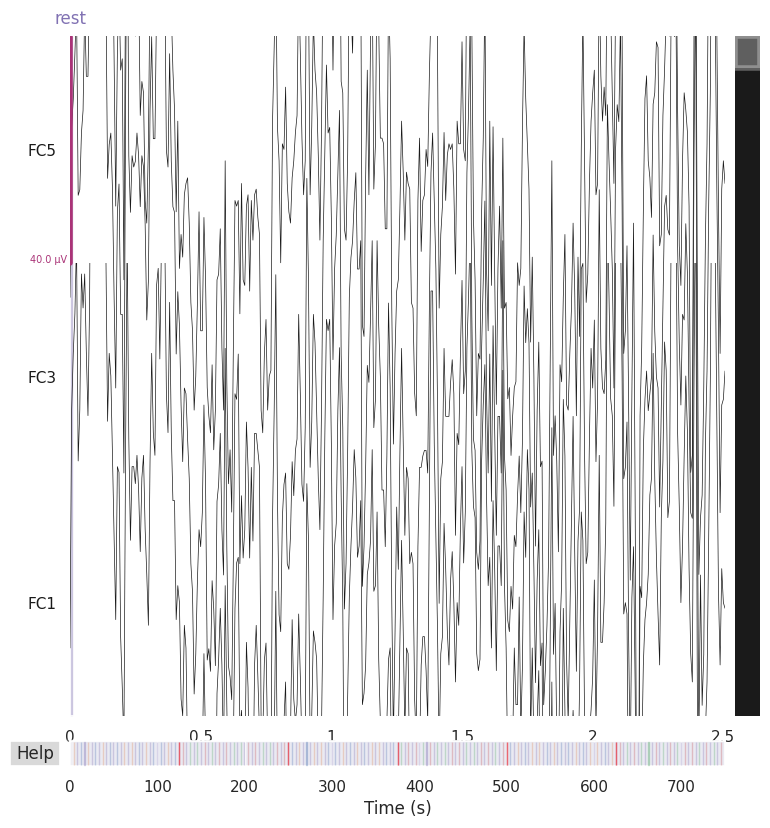

In [10]:
raw.plot(n_channels=3, duration = 2.5)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


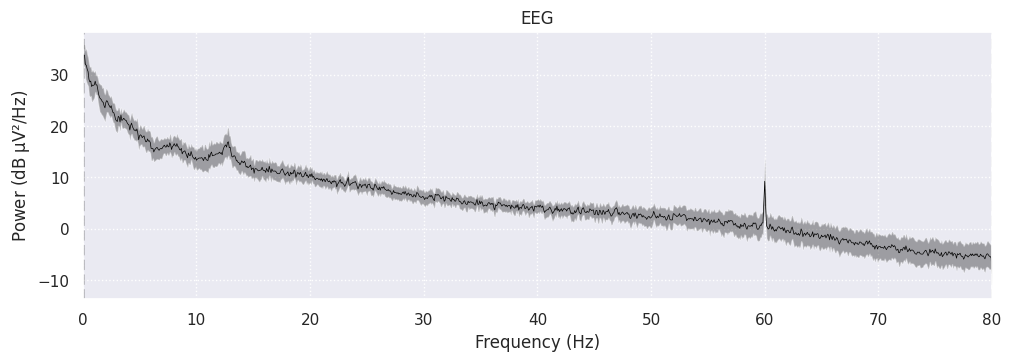

In [11]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


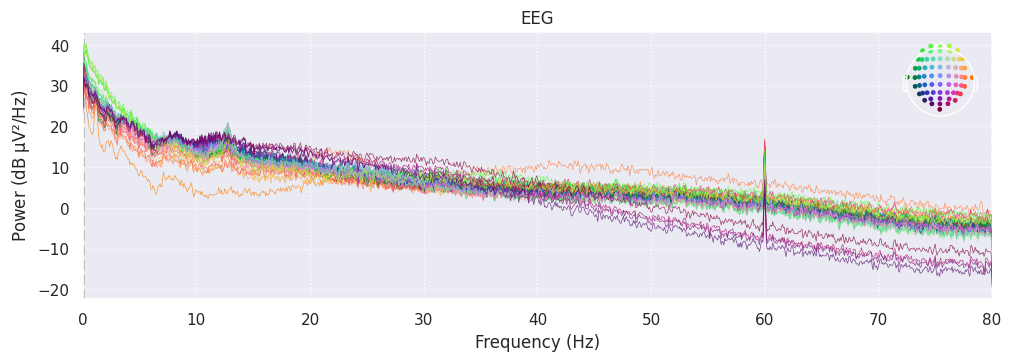

In [12]:
raw.plot_psd(average=False)
plt.show()


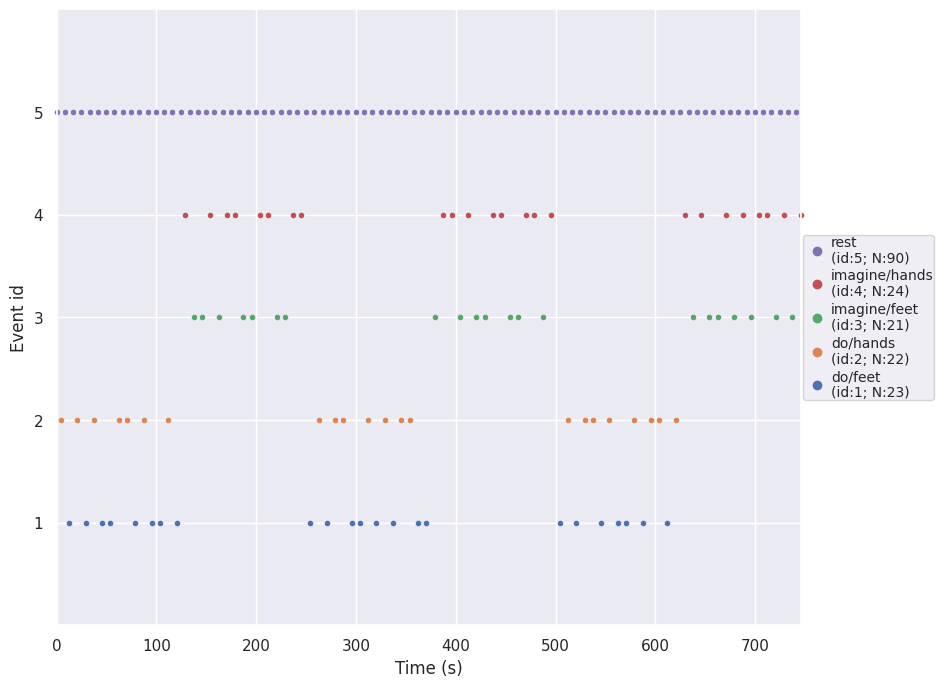

/tmp/ipykernel_1535246/4089939616.py:3: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.7)  # make room for legend


In [13]:
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'],
                          first_samp=raw.first_samp, event_id=event_dict)
fig.subplots_adjust(right=0.7)  # make room for legend


In [14]:
raw.filter(5., 40., fir_design='firwin', skip_by_annotation='edge')


<RawEDF | S001R05.edf, 64 x 120000 (750.0 s), ~58.7 MiB, data loaded>

/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


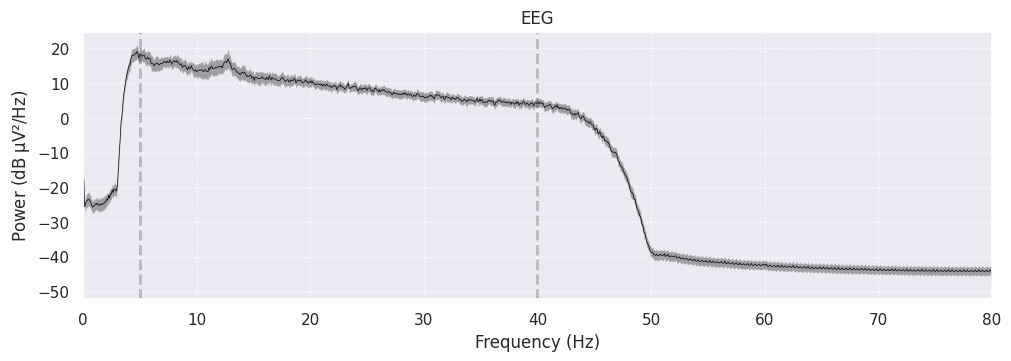

In [15]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


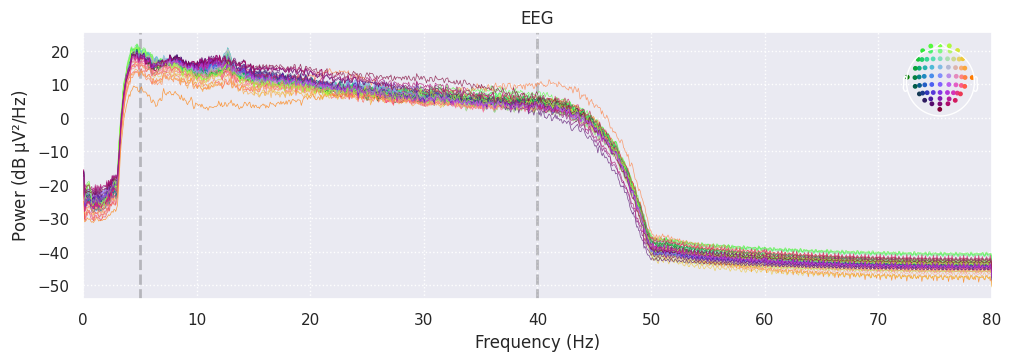

In [16]:
raw.plot_psd(average=False)
plt.show()


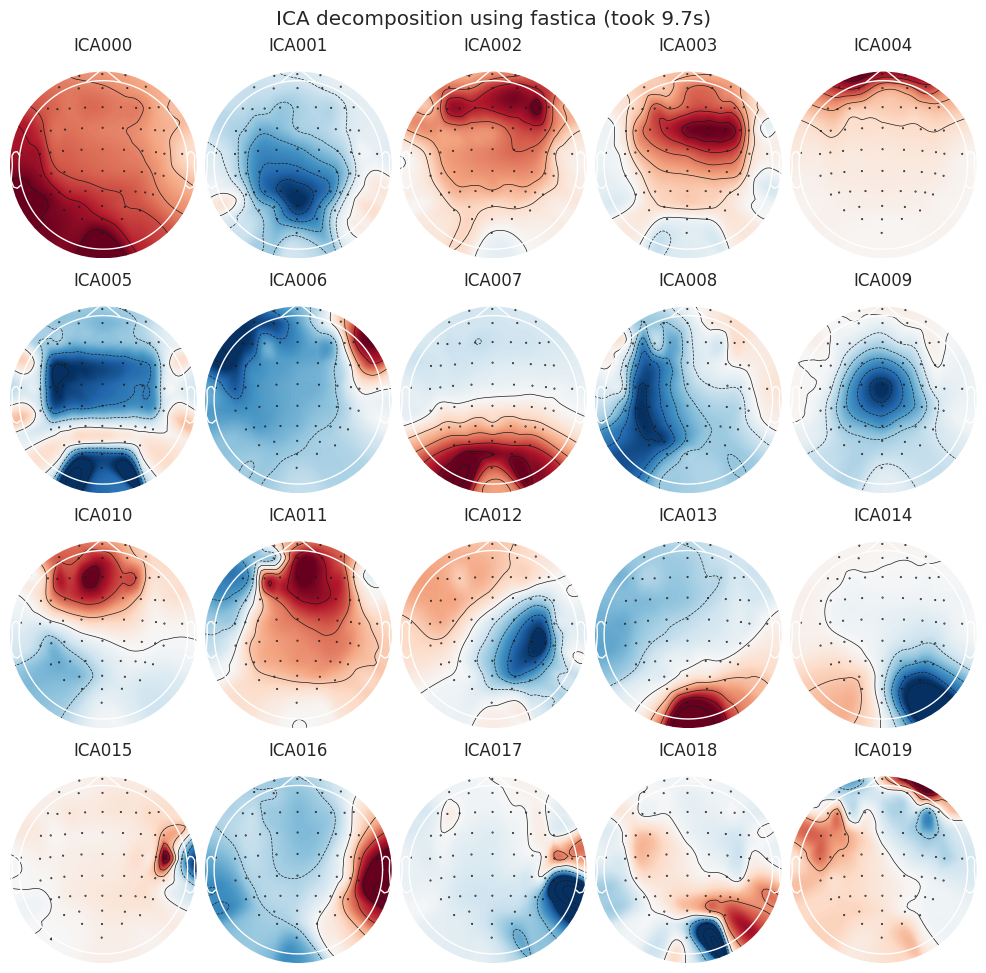

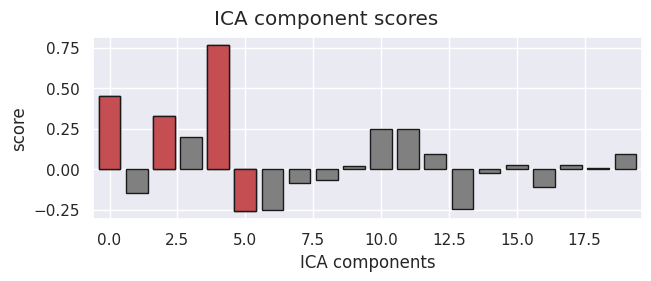

[4, 0, 2, 5] {'eog/0/Fpz': [0, 2, 4, 5], 'eog': [4, 0, 2, 5]}


In [17]:
def run_ica(raw, method, fit_params=None):
    raw_corrected = raw.copy()
    n_components=20
    
    ica = ICA(n_components=n_components, method=method, fit_params=fit_params, random_state=97)
    t0 = time()
    ica.fit(raw_corrected, picks=picks)
    fit_time = time() - t0
    title = ('ICA decomposition using %s (took %.1fs)' % (method, fit_time))
    ica.plot_components(title=title)
    plt.show()
    
    eog_indices, scores = ica.find_bads_eog(raw, ch_name='Fpz',threshold=1.5)
    ica.plot_scores(scores, exclude=eog_indices)  # look at r scores of components
    ica.exclude.extend(eog_indices) 
    raw_corrected = ica.apply(raw_corrected, n_pca_components = n_components, exclude = ica.exclude)
    print(ica.exclude, ica.labels_)
    return raw_corrected

raw_fastica = run_ica(raw, 'fastica')


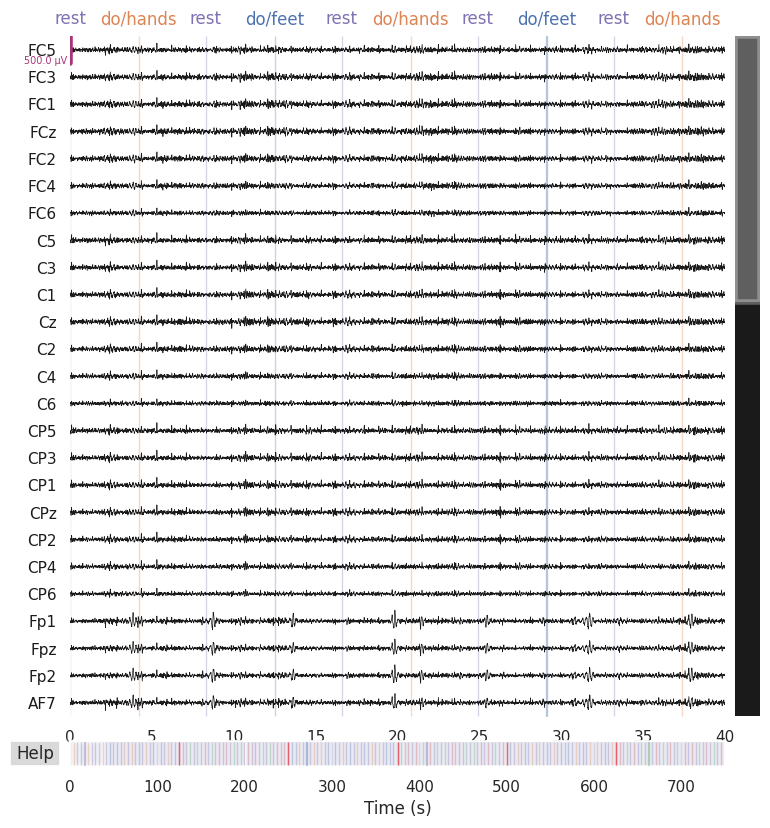

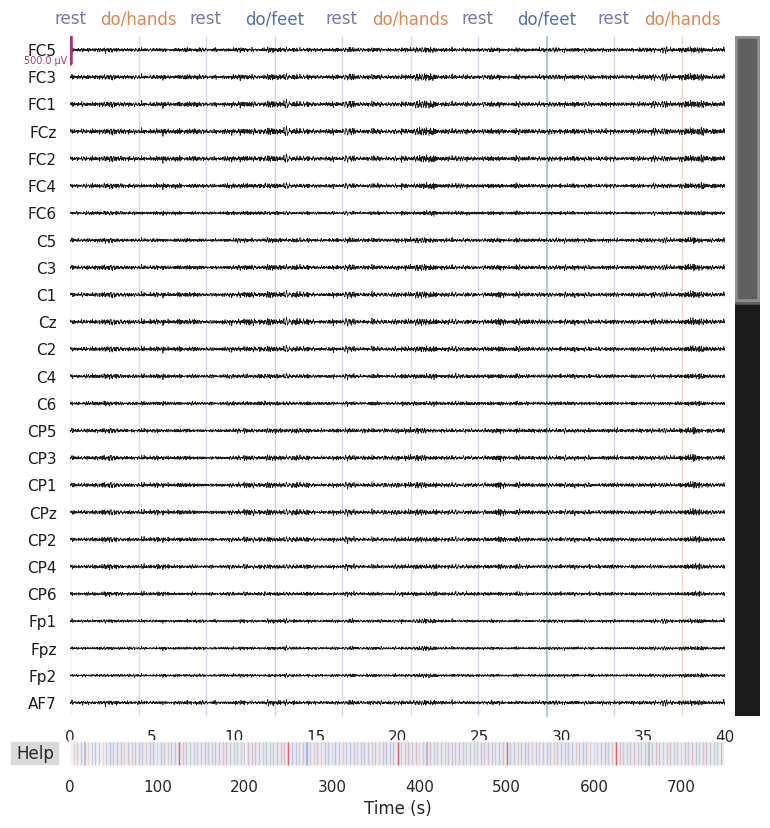

In [18]:
raw.plot(n_channels=25, start=0, duration=40,scalings=dict(eeg=250e-6))
raw_fastica.plot(n_channels=25, start=0, duration=40,scalings=dict(eeg=250e-6))
plt.show()


In [19]:
event_id = {'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4}


In [20]:
tmin, tmax = -1., 4.

events, event_dict = mne.events_from_annotations(raw, event_id=event_id)
print (event_dict)


{'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4}


In [21]:
picks


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [22]:
epochs = Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
epochs


<Epochs | 90 events (all good), -1 – 4 s (baseline off), ~35.3 MiB, data loaded,
 'do/feet': 23
 'do/hands': 22
 'imagine/feet': 21
 'imagine/hands': 24>

In [23]:
labels = epochs.events[:, -1] - 1
labels


array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 3, 2, 2, 3, 2, 3, 3,
       2, 2, 3, 3, 2, 2, 3, 3, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 2, 3, 3, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3, 2, 3, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 3, 2, 3,
       2, 3])

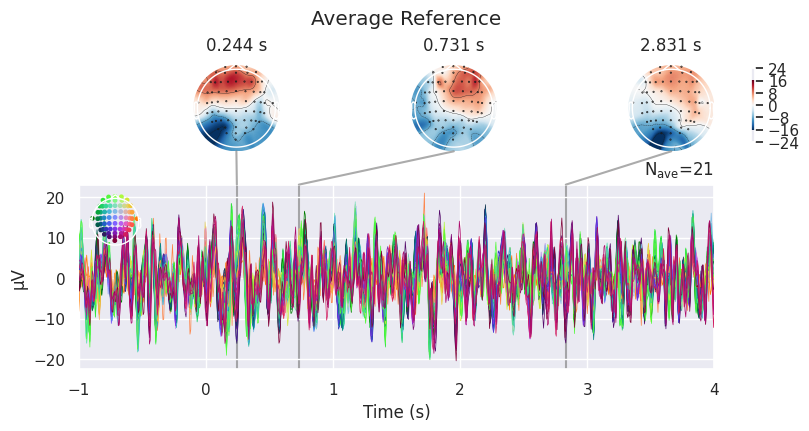

In [24]:
evoked = epochs['imagine/feet'].average()
evoked.plot_joint(title='Average Reference', show=False)
plt.show()


In [ ]:
evoked = epochs['imagine/hands'].average()
evoked.plot_joint(title='Average Reference', show=False)
plt.show()


In [28]:
%matplotlib qt 
times = np.arange(-1, 4, 0.1)
fig, anim = evoked.animate_topomap(times=times, ch_type='eeg', frame_rate=2, time_unit='s', blit=False)


In [27]:
%matplotlib inline
sns.set(rc={'figure.figsize':(12,8)})


# PIPELINE

In [29]:
score_pipeline = -1
models_pipeline = None


In [30]:
# Define a monte-carlo cross-validation generator (reduce variance):
scores = []
epochs_data = epochs.get_data()
cv = ShuffleSplit(10, test_size=0.4, random_state=42)

# # Assemble a classifier
csp = CSP(n_components=10, reg=None, log=True, norm_trace=False)
rfc = RandomForestClassifier(n_estimators=150, random_state=42)

# Use scikit-learn Pipeline with cross_val_score function
clf = make_pipeline(csp, rfc)
scores = cross_val_score(clf, epochs_data, labels, cv=cv, n_jobs=-1)

# Printing the results
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))
if scores.mean() > score_pipeline:
      score_pipeline = scores.mean()
      models_pipeline = clf

# plot CSP patterns estimated on full data for visualization
csp.fit_transform(epochs_data, labels)
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
plt.show()


ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/sklearn/pipeline.py", line 471, in fit
    Xt = self._fit(X, y, routed_params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [31]:
if models_pipeline is None:
    spoc = SPoC(n_components=10, log=True, reg='oas', rank='full')
    rfc = RandomForestClassifier(n_estimators=150, random_state=42)
    models_pipeline = make_pipeline(spoc, rfc)


In [32]:
score_pipeline


-1

In [33]:
models_pipeline


Pipeline(steps=[('spoc',
                 SPoC(log=True, n_components=10, rank='full', reg='oas')),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=150, random_state=42))])

In [34]:
x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.4, random_state=92, shuffle=True)
clf.fit(x_train, y_train)


Pipeline(steps=[('csp', CSP(log=True, n_components=10)),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=150, random_state=42))])

In [35]:
clf.predict(x_test)


array([1, 0, 0, 3, 2, 2, 3, 0, 0, 1, 1, 2, 2, 2, 3, 3, 1, 2, 1, 0, 0, 0,
       3, 1, 1, 0, 1, 0, 0, 2, 1, 1, 2, 0, 1, 3])

In [36]:
clf.score(x_test, y_test)


0.8611111111111112